In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report,confusion_matrix,roc_auc_score,ConfusionMatrixDisplay)

#display settings
pd.set_option('display.max_columns',50)
plt.style.use('seaborn-v0_8')
print("All libraries loaded")

All libraries loaded


In [ ]:
df=pd.read_csv(r"/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(f"Rows:{df.shape[0]}, Columns:{df.shape[1]}")
df.head()

Rows:1470, Columns:35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
# ── How many employees left vs stayed?
print(df['Attrition'].value_counts())
print("\nAttrition rate:",
round(df['Attrition'].value_counts(normalize=True)['Yes'] * 100, 1), "%")

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: 16.1 %


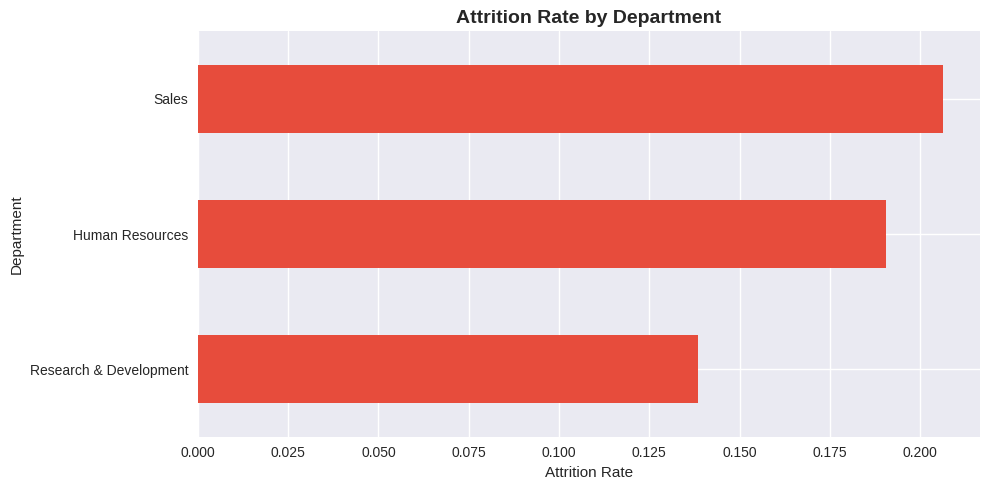

In [ ]:
#chart 1:attrition by department
plt.figure(figsize=(10,5))
dept_attrition=df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack()
dept_attrition['Yes'].sort_values().plot(kind='barh', color='#E74C3C')
plt.title('Attrition Rate by Department',fontsize=14,fontweight='bold')
plt.xlabel('Attrition Rate')
plt.tight_layout()
plt.savefig('chart1_dept_attrition.png', dpi=150)
plt.show()

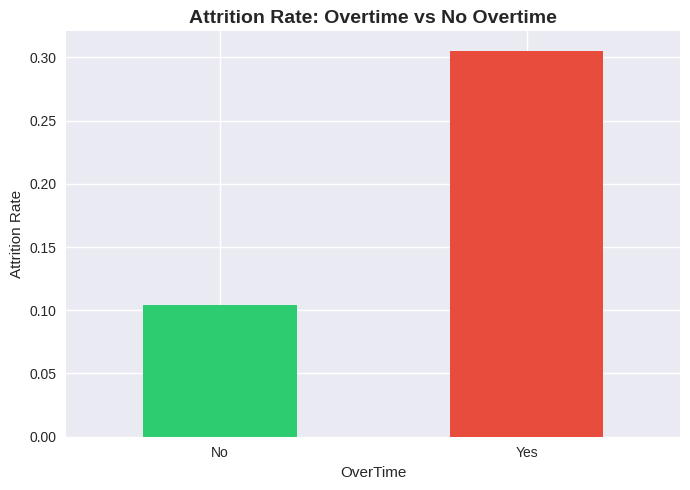

Attrition        No       Yes
OverTime                     
No         0.895636  0.104364
Yes        0.694712  0.305288


In [ ]:
# ── Chart 2: Attrition by OverTime
plt.figure(figsize=(7, 5))
overtime_attr = df.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack()
overtime_attr['Yes'].plot(kind='bar', color=['#2ECC71', '#E74C3C'], rot=0)
plt.title('Attrition Rate: Overtime vs No Overtime', fontsize=14, fontweight='bold')
plt.ylabel('Attrition Rate')
plt.tight_layout()
plt.savefig('chart2_overtime_attrition.png', dpi=150)
plt.show()
print(overtime_attr)

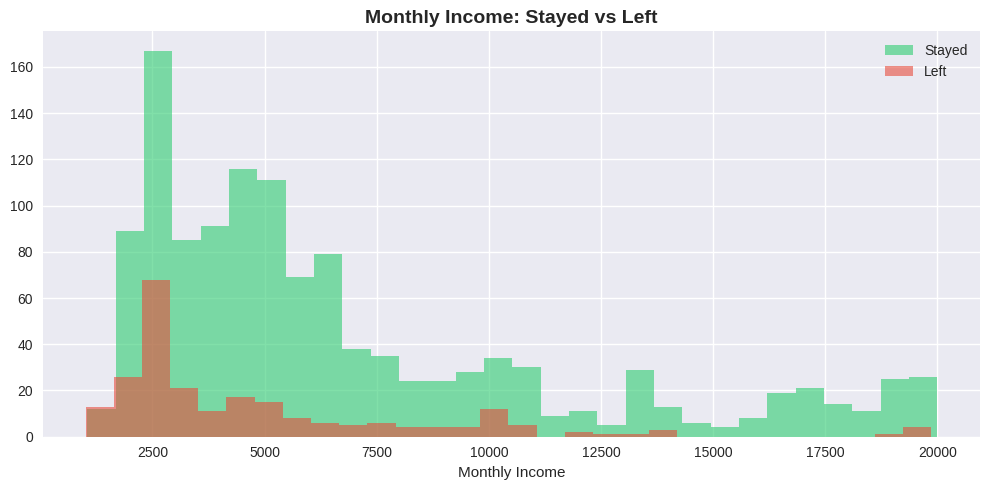

In [ ]:
# ── Chart 3: Monthly Income Distribution
plt.figure(figsize=(10, 5))

df[df['Attrition']=='No']['MonthlyIncome'].hist(
    alpha=0.6, bins=30, color='#2ECC71', label='Stayed'
)
df[df['Attrition']=='Yes']['MonthlyIncome'].hist(
    alpha=0.6, bins=30, color='#E74C3C', label='Left'
)

plt.title('Monthly Income: Stayed vs Left', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Income')
plt.legend()
plt.tight_layout()
plt.savefig('chart3_income_attrition.png', dpi=150)
plt.show()

/tmp/ipykernel_3300/3280381498.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='YearsAtCompany',


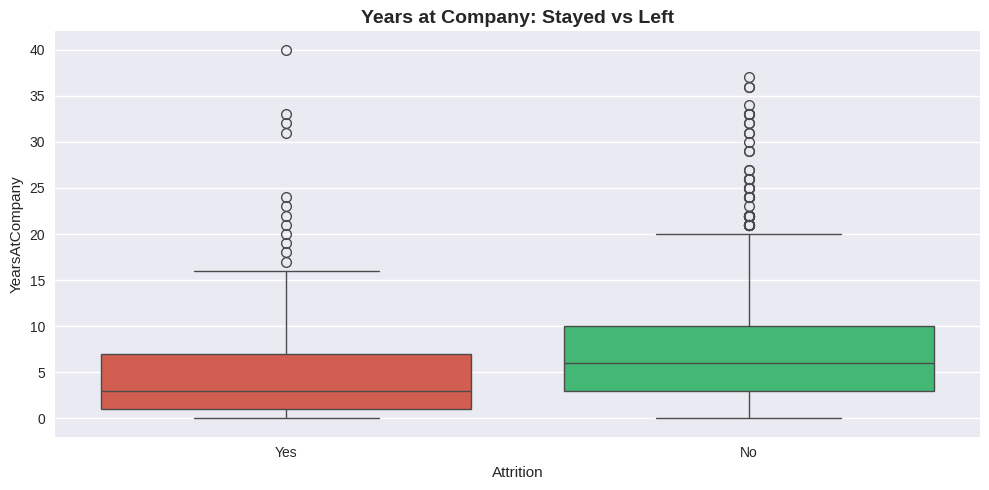

In [ ]:
# ── Chart 4: Years at Company
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Attrition', y='YearsAtCompany',
            palette={'No': '#2ECC71', 'Yes': '#E74C3C'})
plt.title('Years at Company: Stayed vs Left', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_years_attrition.png', dpi=150)
plt.show()

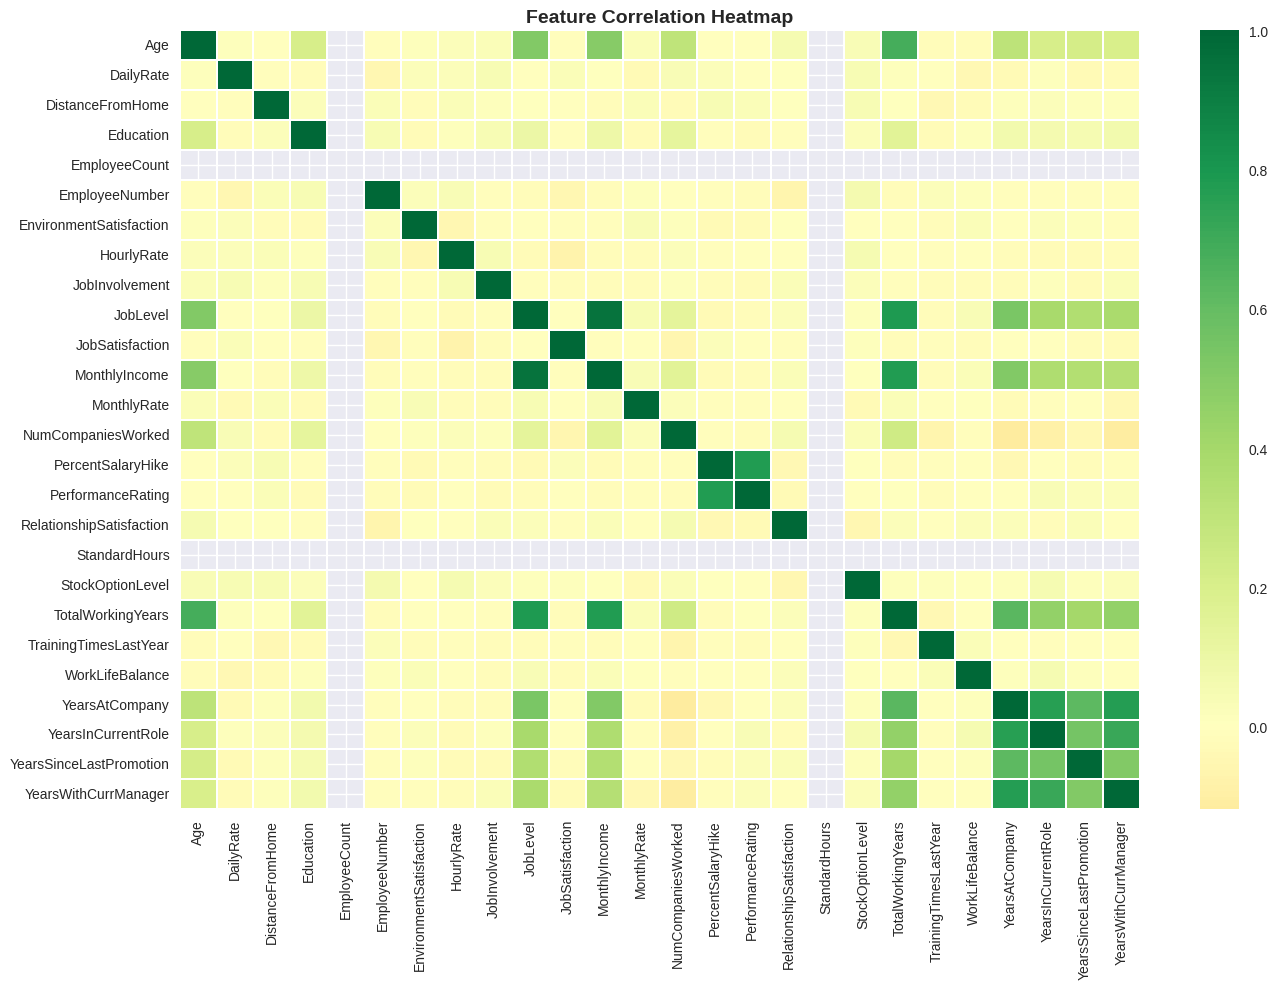

In [ ]:
# ── Chart 5: Correlation Heatmap (numeric columns only)
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()
sns.heatmap(correlation, cmap='RdYlGn', center=0,
            annot=False, linewidths=0.3)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_correlation.png', dpi=150)
plt.show()

In [ ]:
#missing values
print("Missing values:")
print(df.isnull().sum().sum(),"total missing values")

Missing values:
0 total missing values


In [ ]:
df_original = df.copy()

In [ ]:
#drop columns that has 0 information
cols_to_drop=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df=df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} useless columns")
print(f"Remaining columns: {df.shape[1]}")

Dropped 4 useless columns
Remaining columns: 31


In [ ]:
# ── Encode target variable first
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print("Target encoded ✅")
print(df['Attrition'].value_counts())

Target encoded ✅
Attrition
0    1233
1     237
Name: count, dtype: int64


In [ ]:
# ── Find all text columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:", cat_cols)

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [ ]:
# ── Label encode all categorical columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("All categorical columns encoded ✅")
df.head()

All categorical columns encoded ✅


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,94,3,2,7,4,2,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,61,2,2,6,2,1,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,92,2,1,2,3,2,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,56,3,1,6,3,1,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,40,3,1,2,2,1,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2


In [ ]:
#split featues
x=df.drop('Attrition',axis=1)
y=df['Attrition']
print(f"Features shape: {x.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns:\n{list(x.columns)}")

Features shape: (1470, 30)
Target shape: (1470,)

Feature columns:
['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [ ]:
#machine learning train_test_split train=80%,test=20%
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
print(f"Traning set: {x_train.shape[0]} rows")
print(f"Test set: {x_test.shape[0]} rows")

Traning set: 1176 rows
Test set: 294 rows


In [ ]:
#train random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    class_weight={0: 1, 1: 4},
    random_state=42
)

rf_model.fit(x_train, y_train)
print("Model trained ✅")


Model trained ✅


In [ ]:
#predctions on test set
y_pred=rf_model.predict(x_test)
print("="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test,y_pred,target_names=['Stayed','Left']))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Stayed       0.88      0.94      0.91       247
        Left       0.48      0.30      0.37        47

    accuracy                           0.84       294
   macro avg       0.68      0.62      0.64       294
weighted avg       0.81      0.84      0.82       294



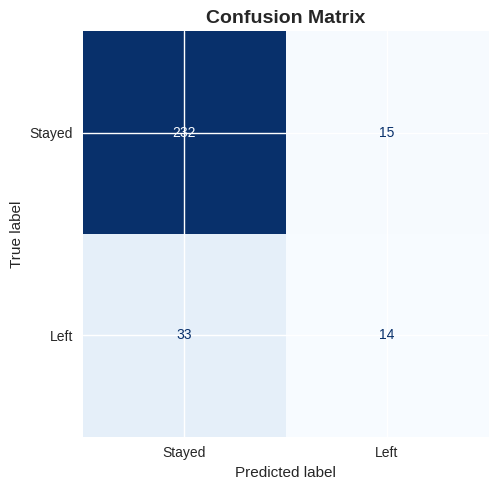

In [ ]:
#confusion matrix
fig,ax=plt.subplots(figsize=(7,5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Stayed', 'Left'],
    colorbar=False,
    cmap='Blues',
    ax=ax)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart6_confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
#roc-auc score
roc_score=roc_auc_score(y_test,rf_model.predict_proba(x_test)[:,1])
print(f"ROC_AOC_SCORE: {round(roc_score,3)}")

ROC_AOC_SCORE: 0.789


In [ ]:
#Individual Employee Risk Scores
proba = rf_model.predict_proba(x_test)[:, 1]

risk_df = pd.DataFrame({
    'Attrition_Probability_%': (proba * 100).round(1),
    'Risk_Level': pd.cut(
        proba,
        bins=[0, 0.3, 0.6, 1.0],
        labels=['🟢 Low', '🟡 Medium', '🔴 High']
    )
}).sort_values('Attrition_Probability_%', ascending=False)

print("=" * 45)
print("   TOP 10 HIGHEST RISK EMPLOYEES")
print("=" * 45)
print(risk_df.head(10).to_string())
print()
print("Risk Distribution:")
print(risk_df['Risk_Level'].value_counts())

   TOP 10 HIGHEST RISK EMPLOYEES
     Attrition_Probability_% Risk_Level
200                     91.9     🔴 High
92                      85.1     🔴 High
223                     84.4     🔴 High
276                     80.9     🔴 High
241                     75.2     🔴 High
9                       71.5     🔴 High
199                     71.3     🔴 High
239                     70.2     🔴 High
106                     69.4     🔴 High
226                     67.5     🔴 High

Risk Distribution:
Risk_Level
🟢 Low       201
🟡 Medium     76
🔴 High       17
Name: count, dtype: int64


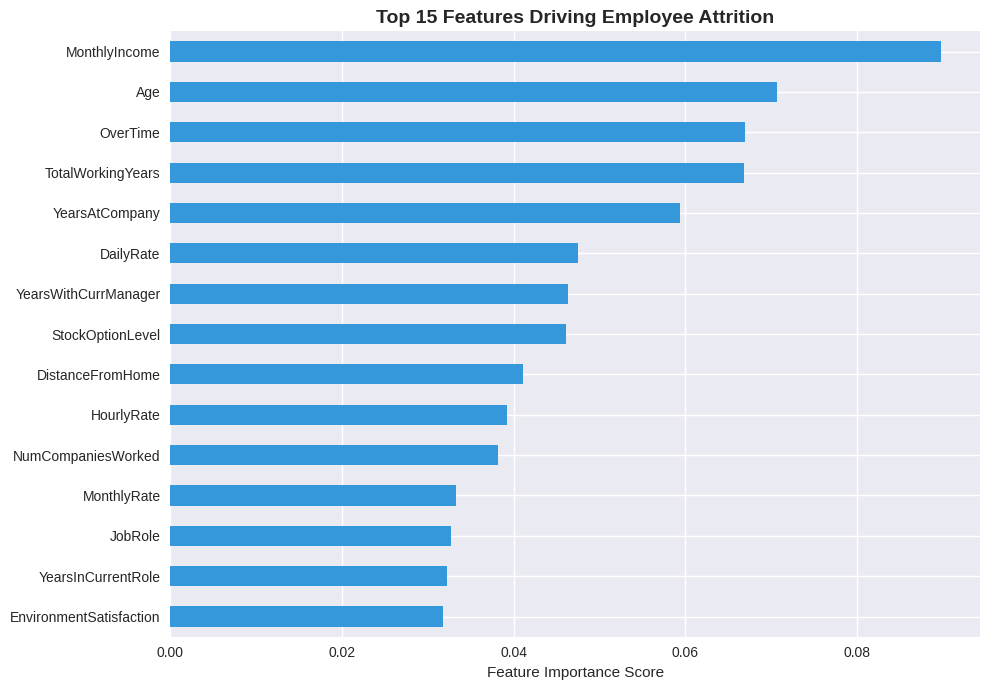


Top 10 features:
MonthlyIncome           0.089832
Age                     0.070684
OverTime                0.066997
TotalWorkingYears       0.066786
YearsAtCompany          0.059390
DailyRate               0.047464
YearsWithCurrManager    0.046336
StockOptionLevel        0.046077
DistanceFromHome        0.041079
HourlyRate              0.039277
dtype: float64


In [ ]:
# Which features matter most?
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

# Top 15 features
plt.figure(figsize=(10, 7))
feature_importance.head(15).sort_values().plot(
    kind='barh',
    color='#3498DB'
)
plt.title('Top 15 Features Driving Employee Attrition',
          fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('chart7_feature_importance.png', dpi=150)
plt.show()

print("\nTop 10 features:")
print(feature_importance.head(10))

In [ ]:
#Department wise Attrition Breakdown
dept_summary = df_original.groupby('Department').agg(
    Total_Employees=('Attrition', 'count'),
    Attrition_Count=('Attrition', lambda x: (x == 'Yes').sum()),
).reset_index()

dept_summary['Attrition_Rate_%'] = (
    dept_summary['Attrition_Count'] /
    dept_summary['Total_Employees'] * 100
).round(1)

dept_summary = dept_summary.sort_values('Attrition_Rate_%', ascending=False)

print("=" * 55)
print("   ATTRITION BREAKDOWN BY DEPARTMENT")
print("=" * 55)
print(dept_summary.to_string(index=False))
print()

# Department-specific recommendations
print("=" * 55)
print("   DEPARTMENT-SPECIFIC RECOMMENDATIONS")
print("=" * 55)
for _, row in dept_summary.iterrows():
    dept = row['Department']
    rate = row['Attrition_Rate_%']
    if rate > 20:
        flag = "🔴 CRITICAL"
        action = "Immediate salary review + workload audit needed"
    elif rate > 12:
        flag = "🟡 MODERATE"
        action = "Quarterly check-ins + career growth discussions"
    else:
        flag = "🟢 HEALTHY"
        action = "Maintain current practices + monitor quarterly"
    print(f"\n{flag} — {dept} ({rate}% attrition)")
    print(f"   → {action}")

   ATTRITION BREAKDOWN BY DEPARTMENT
            Department  Total_Employees  Attrition_Count  Attrition_Rate_%
                 Sales              446               92              20.6
       Human Resources               63               12              19.0
Research & Development              961              133              13.8

   DEPARTMENT-SPECIFIC RECOMMENDATIONS

🔴 CRITICAL — Sales (20.6% attrition)
   → Immediate salary review + workload audit needed

🟡 MODERATE — Human Resources (19.0% attrition)
   → Quarterly check-ins + career growth discussions

🟡 MODERATE — Research & Development (13.8% attrition)
   → Quarterly check-ins + career growth discussions


In [ ]:
#Cost Savings Calculation
print()
print("=" * 55)
print("   ESTIMATED BUSINESS IMPACT")
print("=" * 55)

total_employees    = len(df_original)
attrition_rate     = (df_original['Attrition'] == 'Yes').mean()
current_leavers    = int(total_employees * attrition_rate)
avg_replace_cost   = 50000   # ₹50,000 conservative estimate per employee

high_risk_count    = len(risk_df[risk_df['Risk_Level'] == '🔴 High'])
retention_rate     = 0.50    # if we retain 50% of high-risk employees

employees_saved    = int(high_risk_count * retention_rate)
total_cost_saving  = employees_saved * avg_replace_cost

print(f"\n  Total Employees Analyzed  : {total_employees}")
print(f"  Current Attrition Rate    : {attrition_rate*100:.1f}%")
print(f"  Employees Leaving/Year    : {current_leavers}")
print(f"  High Risk Employees Found : {high_risk_count}")
print(f"  Avg Replacement Cost      : ₹{avg_replace_cost:,}")
print()
print(f"  ✅ If 50% of high-risk employees are retained:")
print(f"     Employees Saved         : {employees_saved}")
print(f"     Estimated Cost Saving   : ₹{total_cost_saving:,.0f}")
print()
print(f"  → Recommended Actions:")
print(f"     1. Flag {high_risk_count} high-risk employees for HR review")
print(f"     2. Priority: Sales dept (highest attrition rate)")
print(f"     3. Immediate focus: Overtime policy + salary benchmarking")


   ESTIMATED BUSINESS IMPACT

  Total Employees Analyzed  : 1470
  Current Attrition Rate    : 16.1%
  Employees Leaving/Year    : 236
  High Risk Employees Found : 17
  Avg Replacement Cost      : ₹50,000

  ✅ If 50% of high-risk employees are retained:
     Employees Saved         : 8
     Estimated Cost Saving   : ₹400,000

  → Recommended Actions:
     1. Flag 17 high-risk employees for HR review
     2. Priority: Sales dept (highest attrition rate)
     3. Immediate focus: Overtime policy + salary benchmarking


In [ ]:
from google.colab import files

# Download the notebook itself
# File → Download → Download .ipynb  (do this manually from menu)

# Download all chart images at once
import os
charts = [f for f in os.listdir() if f.endswith('.png')]
for chart in charts:
    files.download(chart)
    print(f"Downloaded: {chart}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: chart3_income_attrition.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: chart4_years_attrition.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: chart1_dept_attrition.png
